# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what? A model is considered linear if it is linear in its coefficients. This means each coefficient is just multiplied by a variable and then added together. Even if we include things like x^2 or log(x), the model is still linear as long as the coefficients aren’t multiplied together or put inside nonlinear functions
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?) For a dummy variable, the coefficient represents how much the predicted value of y changes when the variable goes from 0 to 1. This means, it tells you the difference between that group and the reference group. The intercept represents the predicted value for the reference group when all other variables are zero.
3. Can linear regression be used for classification? Explain why, or why not. It can be used, but it’s not ideal. Linear regression predicts continuous values, so it can give outputs less than 0 or greater than 1, which don’t make sense for probabilities. Classification problems usually need outputs between 0 and 1, which is why models like logistic regression are preferred.
4. What are signs that your linear model is over-fitting? One major sign is that the model performs very well on the training data but poorly on test data. Other signs include having very large or unstable coefficients, or the model changing a lot when the data changes slightly. It usually means the model is fitting noise instead of real patterns.
5. Clearly explain multi-colinearity using the two-stage least squares technique. Multicollinearity happens when two or more predictors are highly correlated.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis? You can incorportate nonlinear relationships by using a log transformation of the data, which gets rids of skew and bias. Another example is through using interaction terms.
7. What is the interpretation of the slope coefficient in a linear regression? The slope tells you how much y is expected to change when x increases by one unit, while holding all other variables constant. A train/test split divides the data once into two parts: one for training and one for testing. It depends on how the data is split. K-fold cross validation splits the data into multiple parts and rotates which part is used for testing. This gives a more reliable estimate because all data gets used for both training and testing.
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected? Usually,  k is set to 5 or 10. Smaller values are faster but less stable, while larger values are more accurate but take longer.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.

Manhatten is the most expensive neighborhood.

2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [1]:
! git clone https://github.com/ds4e/get_data
%run ./get_data/get_data.py

Cloning into 'get_data'...
remote: Enumerating objects: 121, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 121 (delta 43), reused 31 (delta 30), pack-reused 65 (from 2)
Receiving objects: 100% (121/121), 1.76 MiB | 15.84 MiB/s, done.
Resolving deltas: 100% (56/56), done.
Download complete
Extracting data files...
Data extracted


                    Price     Rating
Neighbourhood                       
Bronx           83.308140  91.654378
Brooklyn       124.595122  92.363497
Manhattan      183.964571  91.801785
Queens         100.012747  91.549057
Staten Island  111.312500  90.843750
Most expensive: Manhattan


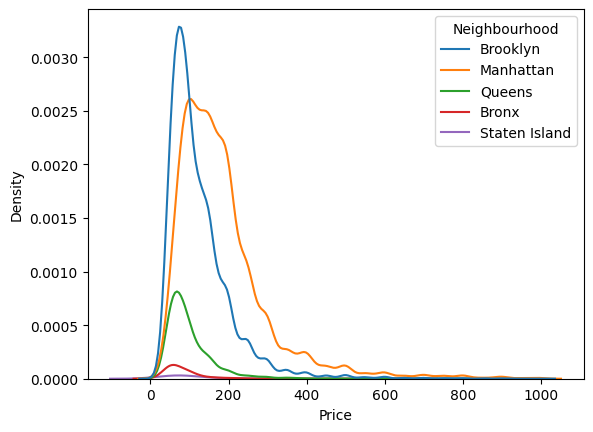

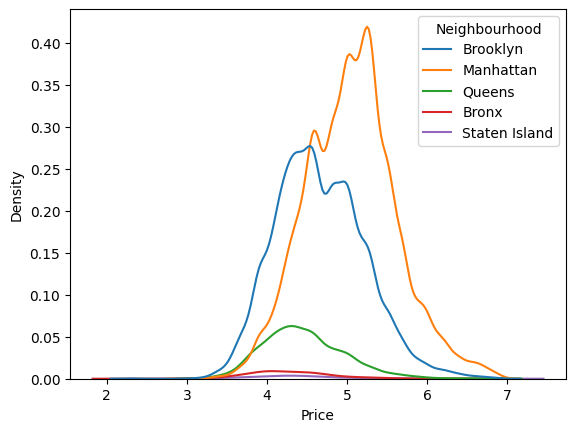

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.092
Model:                            OLS   Adj. R-squared:                  0.092
Method:                 Least Squares   F-statistic:                     764.3
Date:                Mon, 23 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:53:13   Log-Likelihood:            -1.8364e+05
No. Observations:               30297   AIC:                         3.673e+05
Df Residuals:                   30292   BIC:                         3.673e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

df = pd.read_csv('/content/data/airbnb_hw.csv', encoding='utf-8')

df = df.rename(columns={
    "Review Scores Rating": "Rating",
    "Neighbourhood ": "Neighbourhood"
})
# Average Price and Rating by Neighborhood
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

grouped = df.groupby("Neighbourhood")[["Price", "Rating"]].mean()
print(grouped)

most_expensive = grouped["Price"].idxmax()
print("Most expensive:", most_expensive)

# Kernel Density Plots
sns.kdeplot(data=df, x="Price", hue="Neighbourhood")
plt.show()

sns.kdeplot(data=df, x=np.log(df["Price"]), hue="Neighbourhood")
plt.show()

# Regress on Neighbourhood
import statsmodels.formula.api as smf

m1 = smf.ols("Price ~ C(Neighbourhood)", data=df).fit()
print(m1.summary())

# Regress on Rating
m2 = smf.ols("Price ~ Rating", data=df).fit()
print(m2.summary())

# Regress Neighbourhood on Rating
m3 = smf.ols("Price ~ C(Neighbourhood) + Rating", data=df).fit()
print(m3.summary())

# Regress Price on Rating
m4 = smf.ols("Price ~ Rating", data=df).fit()
print(m2.summary())

# Slopes
m5 = smf.ols("Price ~ C(Neighbourhood) * Rating", data=df).fit()
print(m4.summary())

# Cross Validation
df_cv = df[['Price', 'Rating', 'Neighbourhood']].dropna()

y = df_cv['Price']

X2 = df_cv[['Rating']]
model2 = LinearRegression()
cv2 = cross_val_score(model2, X2, y, cv=5, scoring='neg_mean_squared_error')

X3 = df_cv[['Neighbourhood', 'Rating']]
model3 = Pipeline([
    ('preprocess', ColumnTransformer([
        ('cat', OneHotEncoder(drop='first'), ['Neighbourhood'])
    ], remainder='passthrough')),
    ('reg', LinearRegression())
])
cv3 = cross_val_score(model3, X3, y, cv=5, scoring='neg_mean_squared_error')

df_interact = pd.get_dummies(df_cv, columns=['Neighbourhood'], drop_first=True)

dummy_cols = [col for col in df_interact.columns if 'Neighbourhood_' in col]

for col in dummy_cols:
    df_interact[col + '_x_Rating'] = df_interact[col] * df_interact['Rating']

X4 = df_interact[['Rating'] + dummy_cols + [col + '_x_Rating' for col in dummy_cols]]
y4 = df_interact['Price']

model4_cv = LinearRegression()
cv4 = cross_val_score(model4_cv, X4, y4, cv=5, scoring='neg_mean_squared_error')

print("Rating:", -cv2.mean())
print("Neighbourhood + Rating:", -cv3.mean())
print("Interaction:", -cv4.mean())

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?
